<a href="https://colab.research.google.com/github/Fajtos/hzmps-surveillance/blob/main/analysis_aggregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aggregation of HZMPS Simulation Outputs

This notebook combines the T=50 and T=100 simulation results
produced on Kaggle and generates the summary tables and figures.

Inputs:
- `results_T50.csv`  (180 fits, from `simulation_T50/` on Kaggle)
- `results_T100.csv` (90 fits, from `simulation_T100/` on Kaggle)

Outputs:
- `results_combined.csv`
- `table3_headline.csv`
- `fig1_G0_and_accuracy.png`
- `fig2_sigma_eta_rhat.png`



In [1]:
from google.colab import files
uploaded = files.upload()
# Select BOTH results_T50.csv and results_T100.csv

Saving results_T50.csv to results_T50.csv
Saving results_T100.csv to results_T100.csv


Loaded T=50:  180 rows
Loaded T=100: 90 rows

HEADLINE COMPARISON
  N  T50_G0_correct  T100_G0_correct  T50_accuracy  T100_accuracy  T50_sigma_eta_rhat_fail  T100_sigma_eta_rhat_fail
 50             0.6            0.800         0.888          0.942                    0.433                     0.267
100             0.8            0.933         0.895          0.947                    0.633                     0.267
200             0.9            1.000         0.893          0.937                    0.600                     0.033


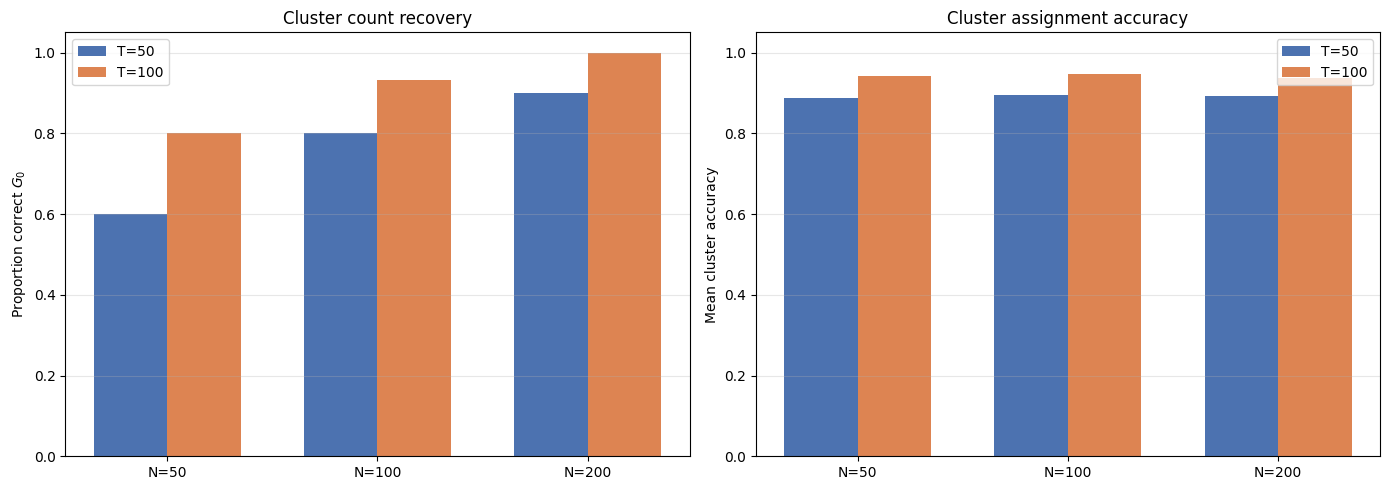

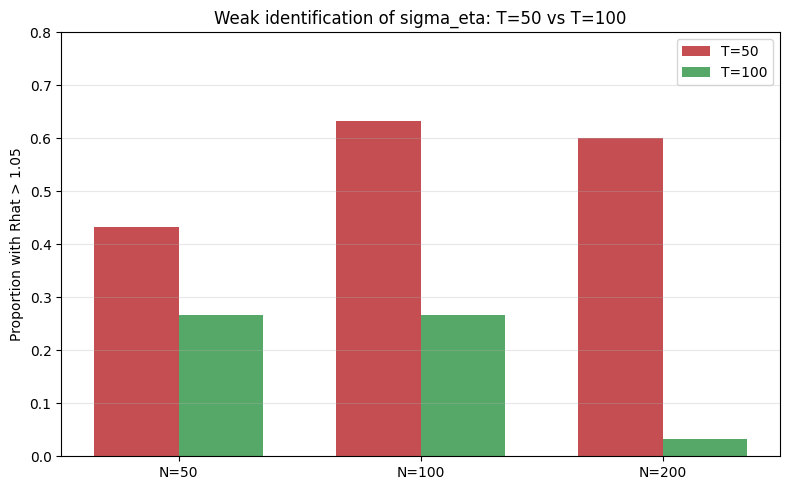

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# Aggregation — combines T=50 and T=100 CSVs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Load ---
df50  = pd.read_csv('results_T50.csv')
df100 = pd.read_csv('results_T100.csv')
df50['study']  = 'T=50'
df100['study'] = 'T=100'

print(f"Loaded T=50:  {len(df50)} rows")
print(f"Loaded T=100: {len(df100)} rows")

# --- Verify expected row counts ---
if len(df50) != 180:
    print(f"WARNING: T=50 has {len(df50)} rows, expected 180")
if len(df100) != 90:
    print(f"WARNING: T=100 has {len(df100)} rows, expected 90")

# Save combined
df_all = pd.concat([df50, df100], ignore_index=True)
df_all.to_csv('results_combined.csv', index=False)

# TABLE 3 — Headline comparison for scenarios 1-3 in both studies
rows = []
for sid in [1, 2, 3]:
    sub50  = df50[df50['scenario_id'] == sid]
    sub100 = df100[df100['scenario_id'] == sid]
    if len(sub50) == 0 or len(sub100) == 0:
        continue
    row = {
        'N': int(sub50['N'].iloc[0]),
        'T50_G0_correct':    round(sub50['G0_correct'].mean(), 3),
        'T100_G0_correct':   round(sub100['G0_correct'].mean(), 3),
        'T50_accuracy':      round(sub50['accuracy'].mean(), 3),
        'T100_accuracy':     round(sub100['accuracy'].mean(), 3),
        'T50_sigma_eta_rhat_fail': round((sub50['sigma_eta_rhat'] > 1.05).mean(), 3),
        'T100_sigma_eta_rhat_fail': round((sub100['sigma_eta_rhat'] > 1.05).mean(), 3),
    }
    rows.append(row)

tbl3 = pd.DataFrame(rows)
print("\nHEADLINE COMPARISON")
print(tbl3.to_string(index=False))
tbl3.to_csv('table3_headline.csv', index=False)

# FIGURE 1 — G0 recovery
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(tbl3))
w = 0.35

axes[0].bar(x - w/2, tbl3['T50_G0_correct'],  w, label='T=50',  color='#4C72B0')
axes[0].bar(x + w/2, tbl3['T100_G0_correct'], w, label='T=100', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"N={n}" for n in tbl3['N']])
axes[0].set_ylabel('Proportion correct $G_0$')
axes[0].set_title('Cluster count recovery')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, tbl3['T50_accuracy'],  w, label='T=50',  color='#4C72B0')
axes[1].bar(x + w/2, tbl3['T100_accuracy'], w, label='T=100', color='#DD8452')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"N={n}" for n in tbl3['N']])
axes[1].set_ylabel('Mean cluster accuracy')
axes[1].set_title('Cluster assignment accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_G0_and_accuracy.png', dpi=150)
plt.show()

# FIGURE 2 — sigma_eta Rhat failure rate
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, tbl3['T50_sigma_eta_rhat_fail'],  w,
       label='T=50',  color='#C44E52')
ax.bar(x + w/2, tbl3['T100_sigma_eta_rhat_fail'], w,
       label='T=100', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels([f"N={n}" for n in tbl3['N']])
ax.set_ylabel('Proportion with Rhat > 1.05')
ax.set_title('Weak identification of sigma_eta: T=50 vs T=100')
ax.set_ylim(0, 0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_sigma_eta_rhat.png', dpi=150)
plt.show()

# Download everything
from google.colab import files
files.download('table3_headline.csv')
files.download('fig1_G0_and_accuracy.png')
files.download('fig2_sigma_eta_rhat.png')
files.download('results_combined.csv')